# E-Commerce Digital Analytics — Python Final Deliverable

## Project Objective
Analyze the performance of an e-commerce business using SQL Server data and Python, covering data extraction, validation, descriptive and diagnostic analysis, product/marketing/device/refund/session analysis, business findings, and predictive modeling using Logistic Regression.

**SQL Server:** `LAPTOP-2IA0EPCJ\SQLEXPRESS`  
**Database:** `PRP_Ecommerce_Analytics`

> Run the notebook from top to bottom before submission so all outputs and charts are visible.

##  Import Libraries

In [224]:
import os, warnings, urllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported successfully.")

Libraries imported successfully.


##  Connect Python to SQL Server

In [225]:

server = r"LAPTOP-2IA0EPCJ\SQLEXPRESS"
database = "PRP_Ecommerce_Analytics"
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;")

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print("SQL Server connection engine created successfully.")
print("Server:", server)
print("Database:", database)

SQL Server connection engine created successfully.
Server: LAPTOP-2IA0EPCJ\SQLEXPRESS
Database: PRP_Ecommerce_Analytics


## Extract Clean Analytical Views

In [226]:
df_orders = pd.read_sql("SELECT * FROM analytics.vw_orders_clean", engine)
df_order_items = pd.read_sql("SELECT * FROM analytics.vw_order_items_clean", engine)
df_products = pd.read_sql("SELECT * FROM analytics.vw_products_clean", engine)
df_refunds = pd.read_sql("SELECT * FROM analytics.vw_refunds_clean", engine)
df_sessions = pd.read_sql("SELECT * FROM analytics.vw_sessions_clean", engine)
df_pageviews = pd.read_sql("SELECT * FROM analytics.vw_pageviews_clean", engine)
df_session_funnel = pd.read_sql("SELECT * FROM analytics.vw_session_funnel", engine)

datasets = {
    "Orders": df_orders,
    "Order Items": df_order_items,
    "Products": df_products,
    "Refunds": df_refunds,
    "Sessions": df_sessions,
    "Pageviews": df_pageviews,
    "Session Funnel": df_session_funnel
}
print("All analytical views loaded successfully.")
for name, df in datasets.items():
    print(f"{name:<15}: {df.shape}")

All analytical views loaded successfully.
Orders         : (32313, 10)
Order Items    : (40025, 8)
Products       : (4, 3)
Refunds        : (1731, 5)
Sessions       : (472871, 11)
Pageviews      : (1188124, 4)
Session Funnel : (472871, 12)


##  Data Validation

In [227]:
for name, df in datasets.items():
    print("\n" + "="*80)
    print(name.upper())
    print("Shape:", df.shape)
    print("Missing Values:")
    print(df.isnull().sum())
    print("Duplicate Rows:", df.duplicated().sum())


ORDERS
Shape: (32313, 10)
Missing Values:
order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
gross_profit_usd      0
gross_margin_pct      0
dtype: int64
Duplicate Rows: 0

ORDER ITEMS
Shape: (40025, 8)
Missing Values:
order_item_id       0
created_at          0
order_id            0
product_id          0
is_primary_item     0
price_usd           0
cogs_usd            0
gross_profit_usd    0
dtype: int64
Duplicate Rows: 0

PRODUCTS
Shape: (4, 3)
Missing Values:
product_id      0
created_at      0
product_name    0
dtype: int64
Duplicate Rows: 0

REFUNDS
Shape: (1731, 5)
Missing Values:
order_item_refund_id    0
created_at              0
order_item_id           0
order_id                0
refund_amount_usd       0
dtype: int64
Duplicate Rows: 0

SESSIONS
Shape: (472871, 11)
Missing Values:
website_session_id       0
created_at               0
user

##  Convert Date Columns

In [228]:
for df in datasets.values():
    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
print("Date conversion completed.")

Date conversion completed.


# PART A — DESCRIPTIVE & DIAGNOSTIC ANALYSIS

##  Executive KPIs

In [229]:
gross_revenue = df_orders["price_usd"].sum()
gross_revenue

np.float64(1938509.7500000002)

In [230]:
total_cogs = df_orders["cogs_usd"].sum()
total_cogs

np.float64(722370.25)

In [231]:
gross_profit = df_orders["gross_profit_usd"].sum() if "gross_profit_usd" in df_orders.columns else gross_revenue-total_cogs
gross_profit

np.float64(1216139.5)

In [232]:
total_refunds = df_refunds["refund_amount_usd"].sum()
total_refunds

np.float64(85338.69)

In [233]:
net_revenue = gross_revenue - total_refunds
net_revenue

np.float64(1853171.0600000003)

In [234]:
total_orders = df_orders["order_id"].nunique()
total_orders

32313

In [235]:
total_sessions = df_session_funnel["website_session_id"].nunique()
total_sessions

472871

In [236]:
converted_sessions = int(df_session_funnel["converted_session"].sum())
converted_sessions

32313

In [237]:
conversion_rate = converted_sessions / total_sessions * 100
conversion_rate

6.833364702001179

In [238]:
average_order_value = gross_revenue / total_orders
average_order_value

np.float64(59.99163649305234)

In [239]:
gross_margin_pct = gross_profit / gross_revenue * 100
gross_margin_pct

np.float64(62.73579485478471)

In [240]:
revenue_per_session = gross_revenue / total_sessions
revenue_per_session

np.float64(4.099447312269097)

In [241]:
refund_pct_of_revenue = total_refunds / gross_revenue * 100
refund_pct_of_revenue

np.float64(4.402283248768803)

In [242]:
business_summary = pd.DataFrame({
    "Metric":["Gross Revenue","Net Revenue","Total Orders","Total Sessions","Converted Sessions","Conversion Rate (%)","Average Order Value","Total COGS","Gross Profit","Gross Margin (%)","Total Refund Amount","Refund % of Revenue","Revenue per Session"],
    "Value":[gross_revenue,net_revenue,total_orders,total_sessions,converted_sessions,conversion_rate,average_order_value,total_cogs,gross_profit,gross_margin_pct,total_refunds,refund_pct_of_revenue,revenue_per_session]
})

display(business_summary)

,Metric,Value
0,Gross Revenue,1.938510e+06
1,Net Revenue,1.853171e+06
2,Total Orders,3.231300e+04
3,Total Sessions,4.728710e+05
4,Converted Sessions,3.231300e+04
5,Conversion Rate (%),6.833365e+00
6,Average Order Value,5.999164e+01
7,Total COGS,7.223702e+05
8,Gross Profit,1.216140e+06
9,Gross Margin (%),6.273579e+01


##  Sales Trend Analysis

In [243]:
df_orders["year"] = df_orders["created_at"].dt.year

In [244]:
revenue_by_year = df_orders.groupby("year")["price_usd"].sum().sort_index()

In [245]:
orders_by_year = df_orders.groupby("year")["order_id"].nunique().sort_index()

In [246]:
profit_by_year = df_orders.groupby("year")["gross_profit_usd"].sum().sort_index() if "gross_profit_usd" in df_orders.columns else (df_orders.assign(gross_profit_usd=df_orders["price_usd"]-df_orders["cogs_usd"]).groupby("year")["gross_profit_usd"].sum().sort_index())

In [247]:
display(pd.DataFrame({"Revenue":revenue_by_year,"Orders":orders_by_year,"Gross Profit":profit_by_year}))

,Revenue,Orders,Gross Profit
year,,,
2012,129274.14,2586,78873.0
2013,393247.87,7447,241596.5
2014,1075612.19,16860,679722.5
2015,340375.55,5420,215947.5


In [248]:
revenue_growth = revenue_by_year.pct_change()*100

In [249]:
order_growth = orders_by_year.pct_change()*100

In [250]:
display(pd.DataFrame({"Revenue Growth %":revenue_growth,"Order Growth %":order_growth}))

,Revenue Growth %,Order Growth %
year,,
2012,NaN,NaN
2013,204.196856,187.973705
2014,173.520157,126.399893
2015,-68.355179,-67.852906


##  Product Analysis

In [251]:
df_product_analysis = df_order_items.merge(df_products[["product_id","product_name"]], on="product_id", how="left")
if "gross_profit_usd" not in df_product_analysis.columns:
    df_product_analysis["gross_profit_usd"] = df_product_analysis["price_usd"] - df_product_analysis["cogs_usd"]

In [252]:
product_summary = df_product_analysis.groupby("product_name").agg(units_sold=("order_item_id","count"), 
                                                                  revenue=("price_usd","sum"), 
                                                                  cogs=("cogs_usd","sum"), 
                                                                  gross_profit=("gross_profit_usd","sum"))


In [253]:
product_summary["gross_margin_pct"] = product_summary["gross_profit"] / product_summary["revenue"] * 100
product_summary = product_summary.sort_values("revenue", ascending=False)
display(product_summary)

,units_sold,revenue,cogs,gross_profit,gross_margin_pct
product_name,,,,,
The Original Mr. Fuzzy,24226,1211057.74,472164.74,738893.0,61.012202
The Forever Love Bear,5796,347702.04,130352.04,217350.0,62.510418
The Birthday Sugar Panda,4985,229260.15,72232.65,157027.5,68.493151
The Hudson River Mini bear,5018,150489.82,47620.82,102869.0,68.356119


##  Refund Analysis

In [254]:
df_refund_product = df_refunds.merge(df_order_items[["order_item_id","product_id"]], on="order_item_id", how="left")\
                               .merge(df_products[["product_id","product_name"]], on="product_id", how="left")

In [255]:
refund_by_product = df_refund_product.groupby("product_name").agg(refund_amount=("refund_amount_usd","sum"), 
                                                                  refund_count=("order_item_id","count"))


In [256]:
refund_analysis = product_summary[["revenue"]].join(refund_by_product, how="left").fillna(0)

In [257]:
refund_analysis["refund_rate_pct"] = refund_analysis["refund_amount"] / refund_analysis["revenue"] * 100

In [258]:
display(refund_analysis.sort_values("refund_rate_pct", ascending=False))

,revenue,refund_amount,refund_count,refund_rate_pct
product_name,,,,
The Birthday Sugar Panda,229260.15,13842.99,301,6.038114
The Original Mr. Fuzzy,1211057.74,61837.63,1237,5.106084
The Forever Love Bear,347702.04,7738.71,129,2.225673
The Hudson River Mini bear,150489.82,1919.36,64,1.275409


##  Marketing Analysis

In [259]:
marketing_analysis = df_session_funnel.groupby("reporting_utm_source").agg(sessions=("website_session_id","nunique"),
                                                                           converted_sessions=("converted_session","sum"), 
                                                                           revenue=("session_revenue","sum"))

In [260]:
marketing_analysis["conversion_rate_pct"] = marketing_analysis["converted_sessions"] / marketing_analysis["sessions"] * 100

In [261]:
marketing_analysis["revenue_per_session"] = marketing_analysis["revenue"] / marketing_analysis["sessions"]

In [262]:
marketing_analysis = marketing_analysis.sort_values("revenue", ascending=False)

In [263]:
display(marketing_analysis)

,sessions,converted_sessions,revenue,conversion_rate_pct,revenue_per_session
reporting_utm_source,,,,,
gsearch,316035,21333,1276144.89,6.750202,4.037986
NULL,83328,6118,371433.03,7.342070,4.457482
bsearch,62823,4519,268672.50,7.193225,4.276658
socialbook,10685,343,22259.33,3.210108,2.083232


## Device Analysis

In [264]:
device_analysis = df_session_funnel.groupby("reporting_device_type").agg(sessions=("website_session_id","nunique"),
                                                                         converted_sessions=("converted_session","sum"),
                                                                         revenue=("session_revenue","sum"))

In [265]:
device_analysis["conversion_rate_pct"] = device_analysis["converted_sessions"] / device_analysis["sessions"] * 100

In [266]:
device_analysis["revenue_per_session"] = device_analysis["revenue"] / device_analysis["sessions"]

In [267]:
display(device_analysis)

,sessions,converted_sessions,revenue,conversion_rate_pct,revenue_per_session
reporting_device_type,,,,,
desktop,327027,27805,1665757.84,8.502356,5.093640
mobile,145844,4508,272751.91,3.090974,1.870162


##  Funnel Analysis

In [268]:
funnel_summary = pd.DataFrame({
                              "Metric":["Total Sessions","Converted Sessions","Total Orders","Total Session Revenue"],
                            "Value":[df_session_funnel["website_session_id"].nunique(),df_session_funnel["converted_session"]
                             .sum(),df_session_funnel["order_count"].sum(),df_session_funnel["session_revenue"].sum()]
                             })

In [269]:
display(funnel_summary)

,Metric,Value
0,Total Sessions,472871.00
1,Converted Sessions,32313.00
2,Total Orders,32313.00
3,Total Session Revenue,1938509.75


##  Repeat vs New Sessions

In [270]:
repeat_analysis = df_session_funnel.groupby("is_repeat_session").agg(sessions=("website_session_id","nunique"),
                            converted_sessions=("converted_session","sum"), revenue=("session_revenue","sum"))

In [271]:
repeat_analysis["conversion_rate_pct"] = repeat_analysis["converted_sessions"] / repeat_analysis["sessions"] * 100

In [272]:
repeat_analysis["revenue_per_session"] = repeat_analysis["revenue"] / repeat_analysis["sessions"]

In [273]:
repeat_analysis.index = repeat_analysis.index.map({0:"New Session",1:"Repeat Session"})

In [274]:
display(repeat_analysis)

,sessions,converted_sessions,revenue,conversion_rate_pct,revenue_per_session
is_repeat_session,,,,,
New Session,394318,26164,1566274.92,6.635254,3.972111
Repeat Session,78553,6149,372234.83,7.827836,4.738646


##  Key Business Findings

In [275]:
top_revenue_product = product_summary["revenue"].idxmax()
top_profit_product = product_summary["gross_profit"].idxmax()
top_margin_product = product_summary["gross_margin_pct"].idxmax()
highest_refund_product = refund_analysis["refund_rate_pct"].idxmax()
best_conversion_source = marketing_analysis["conversion_rate_pct"].idxmax()
best_revenue_source = marketing_analysis["revenue"].idxmax()

print("Top Revenue Product:", top_revenue_product)
print("Top Profit Product:", top_profit_product)
print("Highest Margin Product:", top_margin_product)
print("Highest Refund Rate Product:", highest_refund_product)
print("Best Marketing Source by Conversion:", best_conversion_source)
print("Best Marketing Source by Revenue:", best_revenue_source)

Top Revenue Product: The Original Mr. Fuzzy
Top Profit Product: The Original Mr. Fuzzy
Highest Margin Product: The Birthday Sugar Panda
Highest Refund Rate Product: The Birthday Sugar Panda
Best Marketing Source by Conversion: NULL
Best Marketing Source by Revenue: gsearch


# PART B — VISUALIZATIONS

##  Annual Revenue Trend

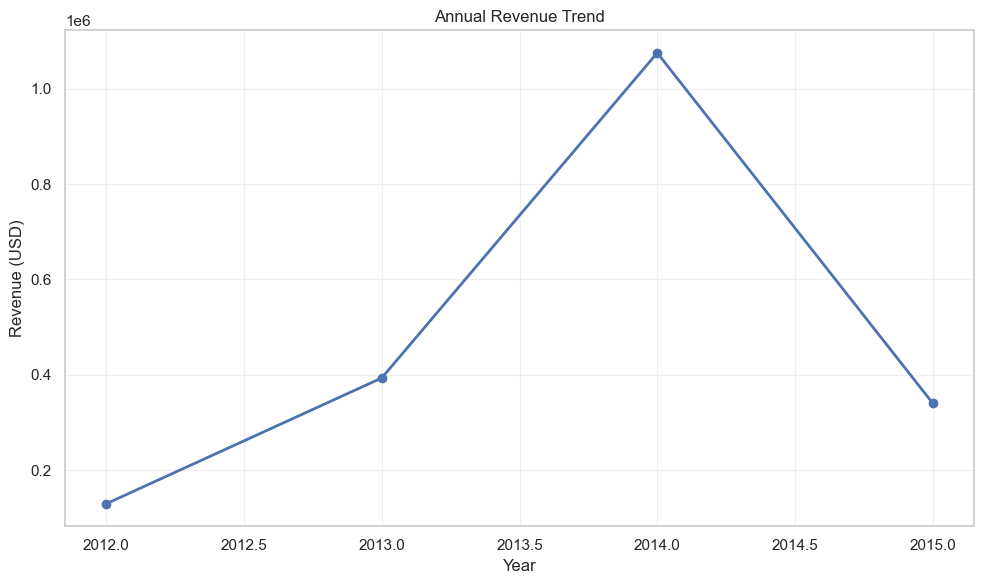

In [276]:
plt.figure(figsize=(10,6)); plt.plot(revenue_by_year.index,revenue_by_year.values,marker="o",linewidth=2) 
plt.title("Annual Revenue Trend"); 
plt.xlabel("Year"); 
plt.ylabel("Revenue (USD)");
plt.grid(True,alpha=.3); 
plt.tight_layout();
plt.show()

## Orders by Year

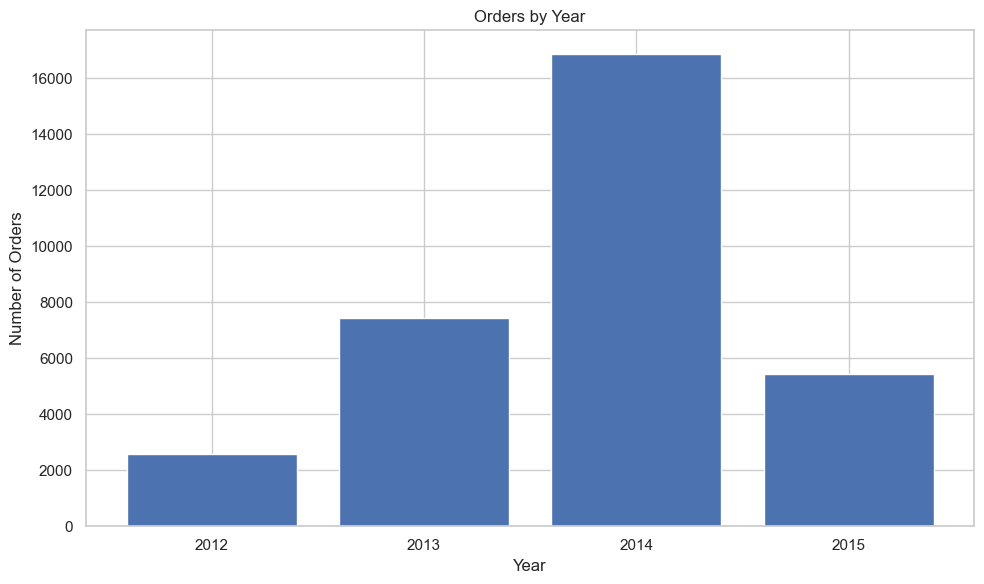

In [277]:
plt.figure(figsize=(10,6))
plt.bar(orders_by_year.index.astype(str),orders_by_year.values)
plt.title("Orders by Year"); plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## Gross Profit Trend

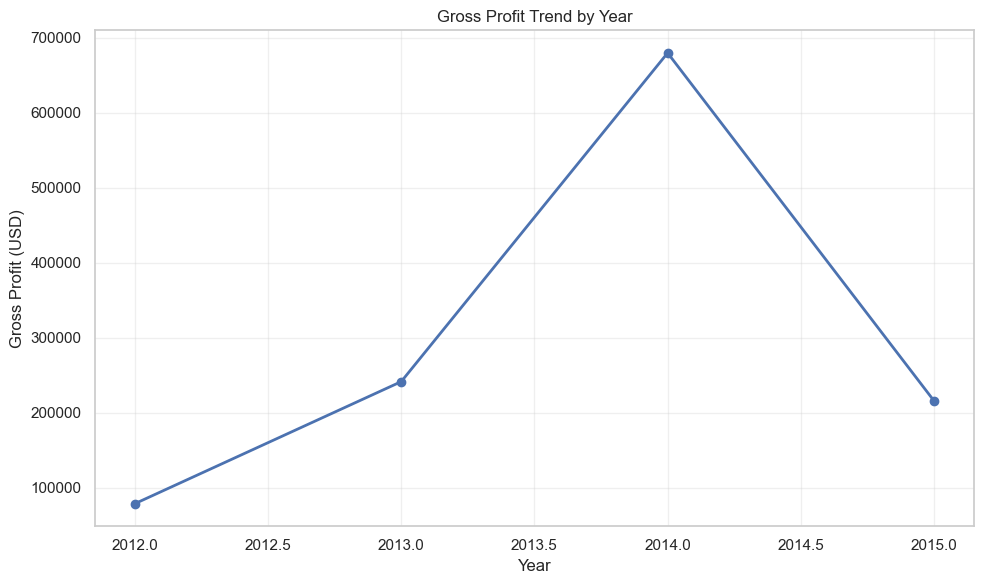

In [278]:
plt.figure(figsize=(10,6))
plt.plot(profit_by_year.index,profit_by_year.values,marker="o",linewidth=2)
plt.title("Gross Profit Trend by Year")
plt.xlabel("Year"); plt.ylabel("Gross Profit (USD)")
plt.grid(True,alpha=.3)
plt.tight_layout()
plt.show()

##  Revenue by Product

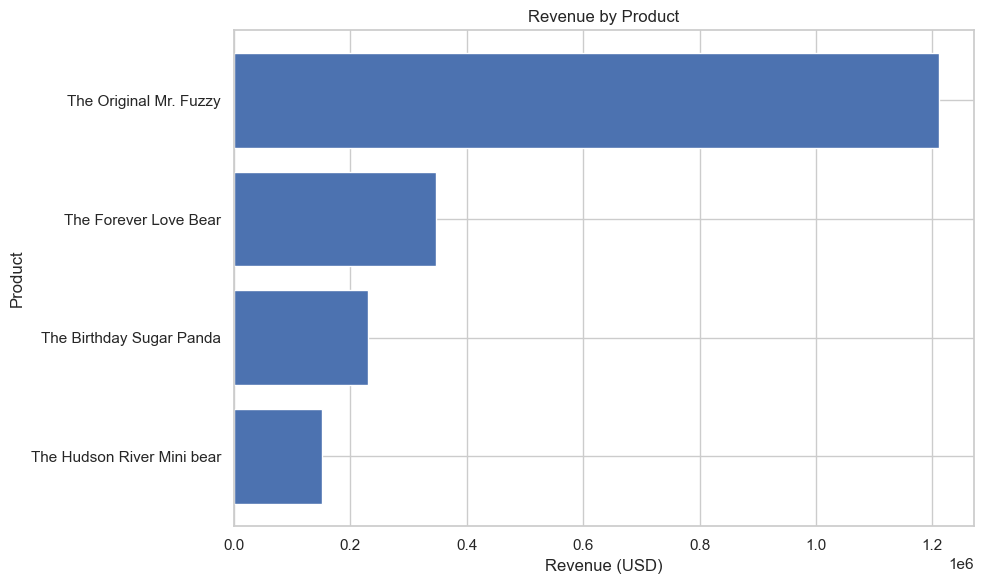

In [279]:
chart_df = product_summary.sort_values("revenue")
plt.figure(figsize=(10,6))
plt.barh(chart_df.index,chart_df["revenue"])
plt.title("Revenue by Product")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

##  Gross Profit by Product

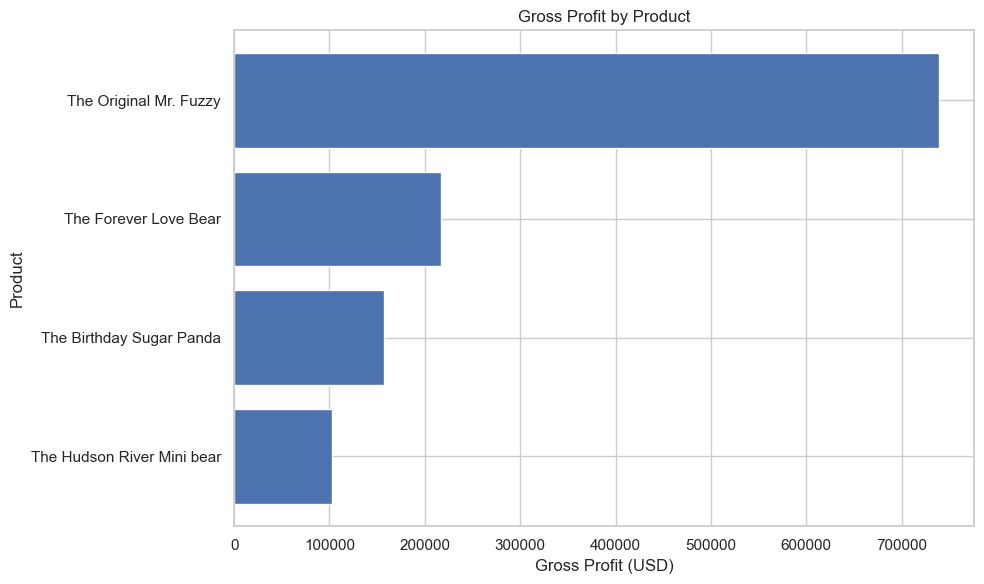

In [280]:
chart_df=product_summary.sort_values("gross_profit")
plt.figure(figsize=(10,6))
plt.barh(chart_df.index,chart_df["gross_profit"])
plt.title("Gross Profit by Product")
plt.xlabel("Gross Profit (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

##  Sessions by Marketing Source

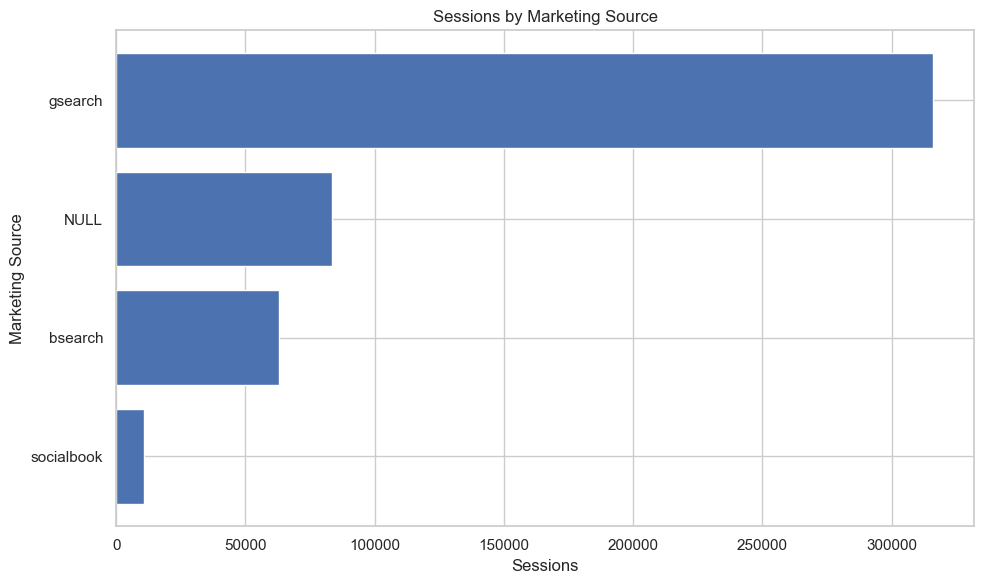

In [281]:
s = marketing_analysis["sessions"].sort_values()
plt.figure(figsize=(10,6))
plt.barh(s.index.astype(str),s.values)
plt.title("Sessions by Marketing Source")
plt.xlabel("Sessions")
plt.ylabel("Marketing Source")
plt.tight_layout()
plt.show()

##  Conversion Rate by Marketing Source

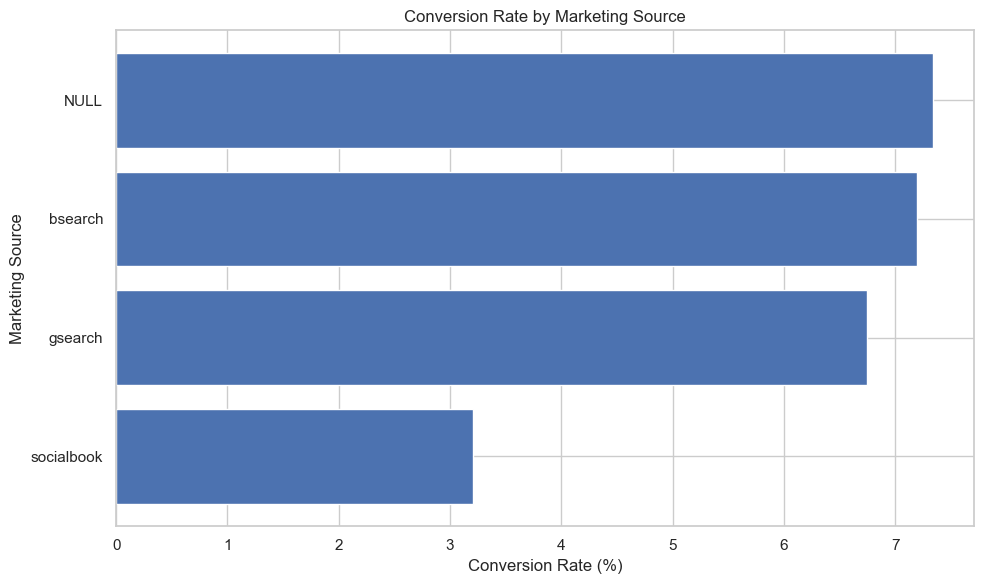

In [282]:
s = marketing_analysis["conversion_rate_pct"].sort_values()
plt.figure(figsize=(10,6))
plt.barh(s.index.astype(str),s.values)
plt.title("Conversion Rate by Marketing Source")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Marketing Source")
plt.tight_layout()
plt.show()

##  Sessions by Device

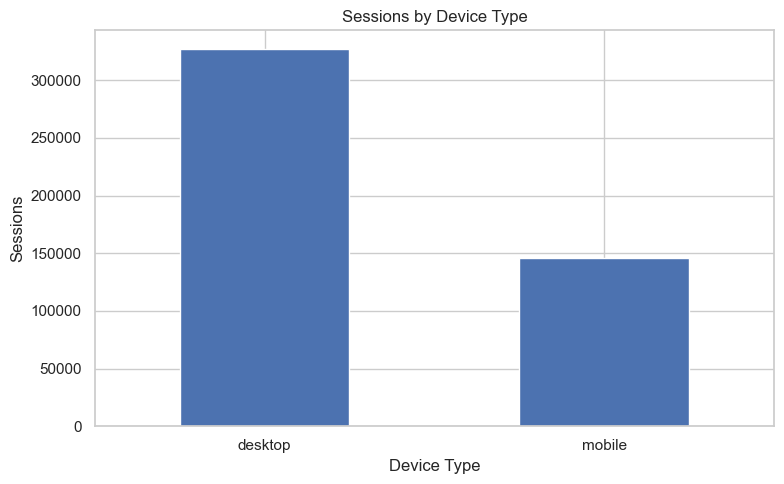

In [283]:
device_analysis["sessions"].plot(kind="bar",figsize=(8,5))
plt.title("Sessions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##  Conversion Rate by Device

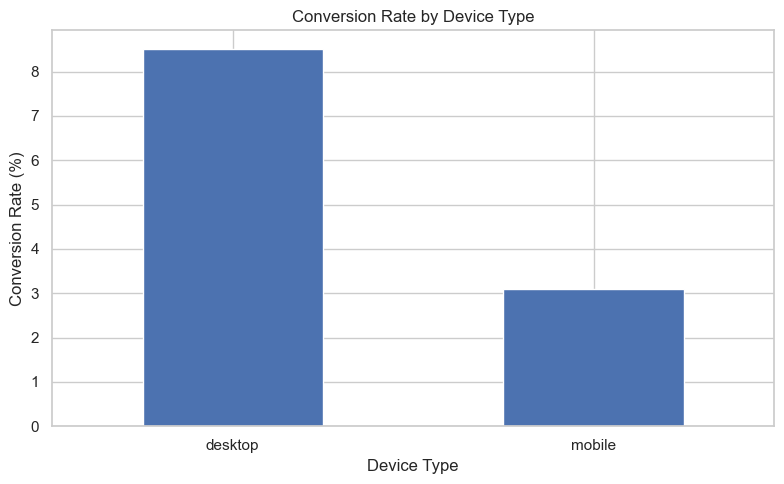

In [284]:
device_analysis["conversion_rate_pct"].plot(kind="bar",figsize=(8,5))
plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##  Refund Amount by Product

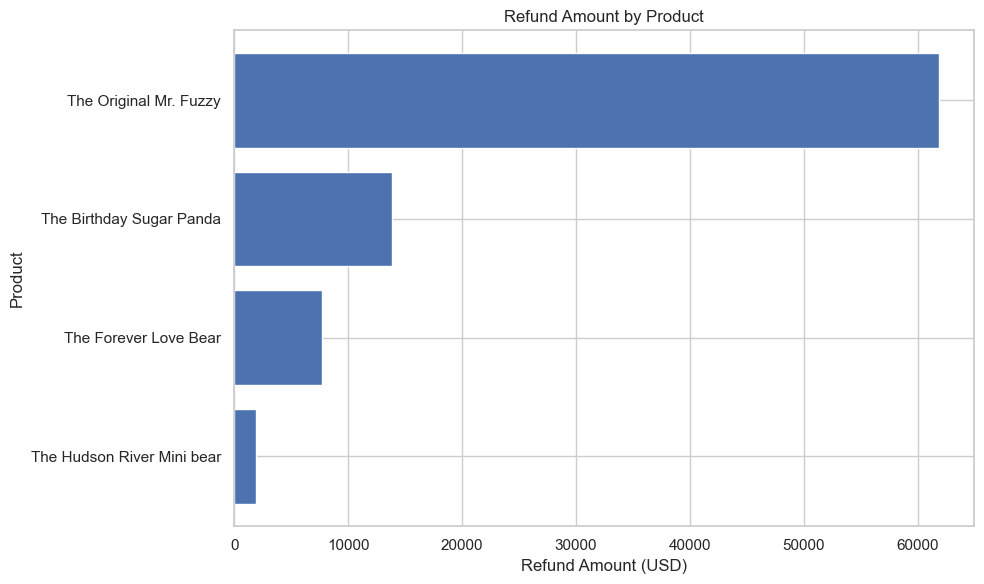

In [285]:
chart_df=refund_analysis.sort_values("refund_amount")
plt.figure(figsize=(10,6))
plt.barh(chart_df.index,chart_df["refund_amount"])
plt.title("Refund Amount by Product")
plt.xlabel("Refund Amount (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

##  Refund Rate by Product

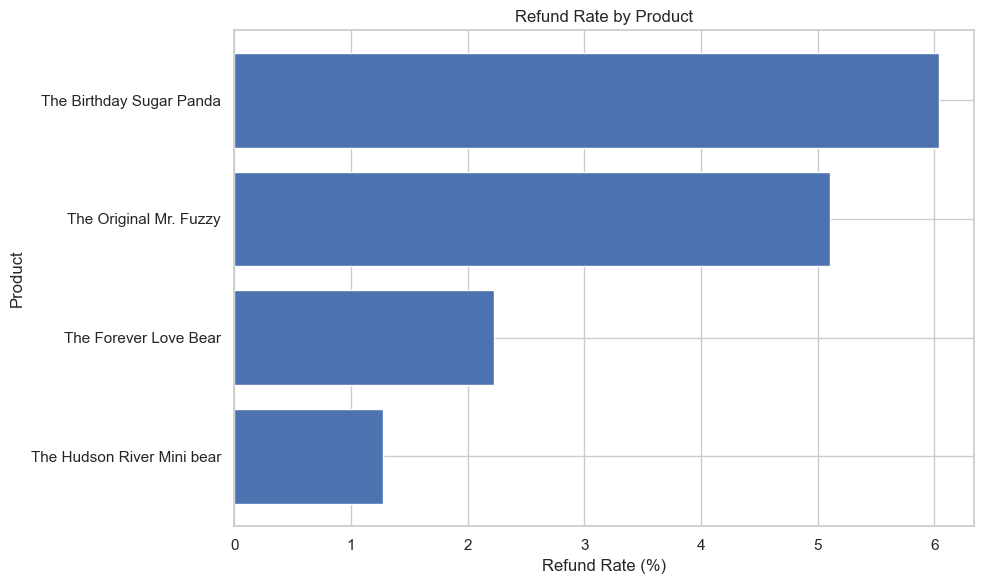

In [286]:
chart_df = refund_analysis.sort_values("refund_rate_pct")
plt.figure(figsize=(10,6))
plt.barh(chart_df.index,chart_df["refund_rate_pct"])
plt.title("Refund Rate by Product")
plt.xlabel("Refund Rate (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# PART C — PREDICTIVE ANALYSIS

##  Machine Learning Objective
Predict whether a website session converts into an order using Logistic Regression.

**Target:** `converted_session` (`0` = not converted, `1` = converted)

**Leakage control:** `order_count` and `session_revenue` are intentionally excluded because they reveal the outcome.

In [287]:
print(df_session_funnel["converted_session"].value_counts())

converted_session
0    440558
1     32313
Name: count, dtype: int64


In [288]:
print(df_session_funnel["converted_session"].value_counts(normalize=True)*100)

converted_session
0    93.166635
1     6.833365
Name: proportion, dtype: float64


##  Prepare ML Dataset

In [289]:
ml_df = df_session_funnel[["website_session_id","created_at","is_repeat_session","reporting_utm_source","utm_campaign","utm_content","reporting_device_type","http_referer","converted_session"]].copy()

In [290]:
ml_df["created_at"] = pd.to_datetime(ml_df["created_at"],errors="coerce")

In [291]:
ml_df["session_hour"] = ml_df["created_at"].dt.hour

In [292]:
ml_df["day_of_week"] = ml_df["created_at"].dt.dayofweek

In [293]:
ml_df["session_month"] = ml_df["created_at"].dt.month

In [294]:
ml_df["session_year"] = ml_df["created_at"].dt.year

In [295]:
ml_df = ml_df.drop(columns=["website_session_id","created_at"])

In [296]:
print("ML Dataset Shape:", ml_df.shape)

ML Dataset Shape: (472871, 11)


In [297]:
display(ml_df.head())

,is_repeat_session,reporting_utm_source,utm_campaign,utm_content,reporting_device_type,http_referer,converted_session,session_hour,day_of_week,session_month,session_year
0,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,0,8,0,3,2012
1,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,8,0,3,2012
2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,8,0,3,2012
3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,8,0,3,2012
4,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,0,9,0,3,2012


## Train/Test Split

In [298]:
from sklearn.model_selection import train_test_split

X = ml_df.drop(columns=["converted_session"])
y = ml_df["converted_session"]

X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (378296, 10)
Testing Shape: (94575, 10)


## Preprocessing

In [299]:
categorical_features=["reporting_utm_source","utm_campaign","utm_content","reporting_device_type","http_referer"]

numeric_features=["is_repeat_session","session_hour","day_of_week","session_month","session_year"]

##  Pipeline

In [300]:
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [301]:
numeric_pipeline = Pipeline([
                           ("imputer", SimpleImputer(strategy = "median")),
                           ("scaler", StandardScaler())
                          ])
numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [302]:
categorical_pipeline = Pipeline([
                               ("imputer", SimpleImputer(strategy = "most_frequent")),
                               ("onehot", OneHotEncoder(handle_unknown = "ignore"))
                            ])
categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [303]:
from sklearn.compose import ColumnTransformer

In [304]:
preprocessor=ColumnTransformer([
                                ("numeric", numeric_pipeline,numeric_features),
                                ("categorical", categorical_pipeline,categorical_features)
                               ])
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['is_repeat_session', 'session_hour',
                                  'day_of_week', 'session_month',
                                  'session_year']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['reporting_utm_source', 'utm_campaign',
                                  'utm_content', 'reporting_device_type',
                                  'http_referer'])])

## Logistic Regression

In [305]:
from sklearn.linear_model import LogisticRegression

In [306]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

In [307]:
model_pipeline = Pipeline([
                        ("preprocessor", preprocessor),
                        ("model", logistic_model)
                        ])
print("Model pipeline created successfully.")
model_pipeline

Model pipeline created successfully.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_repeat_session',
                                                   'session_hour',
                                                   'day_of_week',
                                                   'session_month',
                                                   'session_year']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['reporting_utm_source',
                                                   'utm_campaign',
                                                   'utm_content',
                                                   'reporting_device_type',
                                                   'http_referer'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Model Training 

In [308]:
print("Model trained successfully.")
model_pipeline.fit(X_train,y_train)

Model trained successfully.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_repeat_session',
                                                   'session_hour',
                                                   'day_of_week',
                                                   'session_month',
                                                   'session_year']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['reporting_utm_source',
                                                   'utm_campaign',
                                                   'utm_content',
                                                   'reporting_device_type',
                                                   'http_referer'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

##  Model Prediction

In [309]:
y_pred = model_pipeline.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [310]:
y_probability = model_pipeline.predict_proba(X_test)[:,1]
y_probability

array([0.03400828, 0.05454237, 0.12990818, ..., 0.03454239, 0.09779895,
       0.02389262])

##  Model Evaluation

In [311]:
from sklearn.metrics import accuracy_score,\
                            precision_score,\
                            recall_score,\
                            f1_score,\
                            roc_auc_score,\
                            classification_report,\
                            confusion_matrix,\
                            roc_curve

In [312]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9316627015596087

In [313]:
precision = precision_score(y_test, y_pred)
precision

0.0

In [314]:
recall = recall_score(y_test, y_pred)
recall

0.0

In [315]:
f1 = f1_score(y_test, y_pred)
f1

0.0

In [316]:
roc_auc = roc_auc_score(y_test, y_probability)
roc_auc

np.float64(0.6321677566292697)

In [317]:
model_performance=pd.DataFrame({
                               "Metric":["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
                                "Score":[accuracy,precision,recall,f1,roc_auc]
                               })
model_performance

,Metric,Score
0,Accuracy,0.931663
1,Precision,0.000000
2,Recall,0.000000
3,F1 Score,0.000000
4,ROC-AUC,0.632168


In [318]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     88112
           1       0.00      0.00      0.00      6463

    accuracy                           0.93     94575
   macro avg       0.47      0.50      0.48     94575
weighted avg       0.87      0.93      0.90     94575



##  Confusion Matrix

In [319]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[88112,     0],
       [ 6463,     0]])

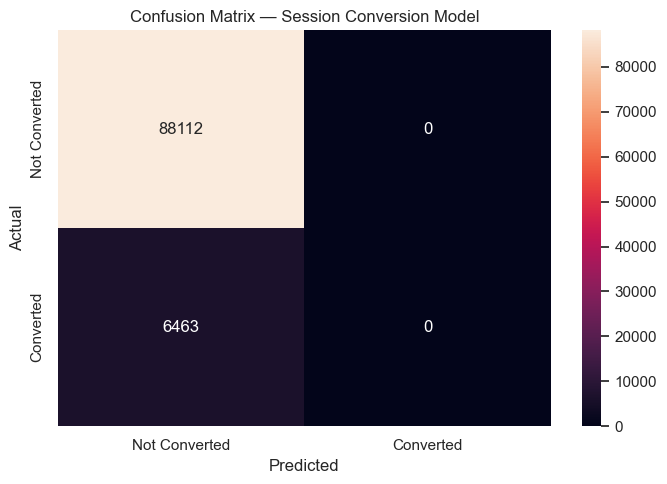

In [320]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Not Converted","Converted"], yticklabels=["Not Converted","Converted"])
plt.title("Confusion Matrix — Session Conversion Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve

In [321]:
fpr, tpr, thresholds = roc_curve(y_test,y_probability)
print("fpr : ",fpr)
print("\n\ntpr : ",tpr)
print("\n\nthresholds : ",thresholds)

fpr :  [0.00000000e+00 1.13491919e-05 3.40475758e-05 ... 9.99943254e-01
 9.99988651e-01 1.00000000e+00]


tpr :  [0. 0. 0. ... 1. 1. 1.]


thresholds :  [       inf 0.1321698  0.13201773 ... 0.01105507 0.01104701 0.01104058]


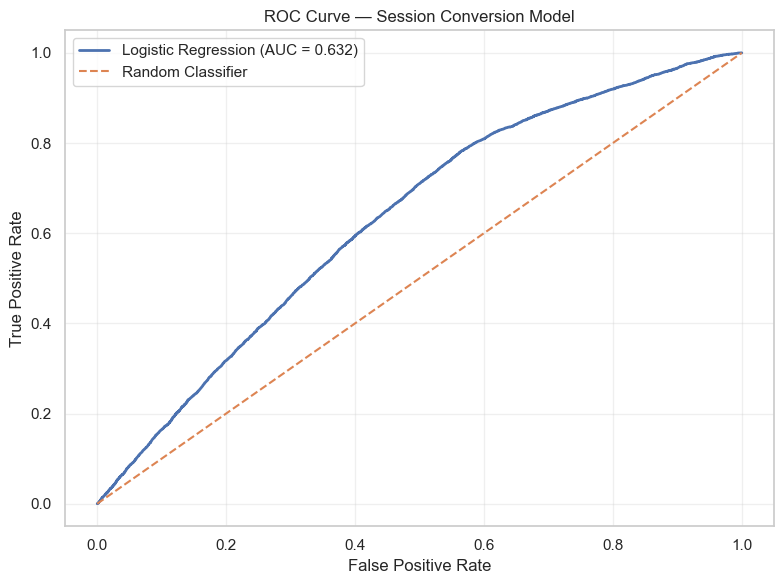

In [322]:
plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle = "--", label = "Random Classifier")
plt.title("ROC Curve — Session Conversion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

##  Feature Interpretation

In [323]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [324]:
coefficients = model_pipeline.named_steps["model"].coef_[0]

In [325]:
feature_importance = pd.DataFrame({"feature":feature_names, "coefficient":coefficients})

In [326]:
print("Top Positive Features:")
display(feature_importance.sort_values("coefficient", ascending=False).head(10))

Top Positive Features:


,feature,coefficient
4,numeric__session_year,0.218510
3,numeric__session_month,0.051489
0,numeric__is_repeat_session,0.045009
1,numeric__session_hour,0.003802
2,numeric__day_of_week,0.001352
18,categorical__utm_content_g_ad_2,-0.103531
17,categorical__utm_content_g_ad_1,-0.114876
16,categorical__utm_content_b_ad_2,-0.118201
21,categorical__reporting_device_type_desktop,-0.119327
15,categorical__utm_content_b_ad_1,-0.188224


In [327]:
print("Top Negative Features:")
display(feature_importance.sort_values("coefficient", ascending=True).head(10))

Top Negative Features:


,feature,coefficient
22,categorical__reporting_device_type_mobile,-1.212927
8,categorical__reporting_utm_source_socialbook,-0.594597
26,categorical__http_referer_https://www.socialbo...,-0.594597
13,categorical__utm_campaign_pilot,-0.368450
19,categorical__utm_content_social_ad_1,-0.368450
6,categorical__reporting_utm_source_bsearch,-0.306425
12,categorical__utm_campaign_nonbrand,-0.303100
25,categorical__http_referer_https://www.gsearch.com,-0.279614
23,categorical__http_referer_NULL,-0.231157
24,categorical__http_referer_https://www.bsearch.com,-0.226886


##  Prediction Results

In [328]:
prediction_results = X_test.copy()

In [329]:
prediction_results["actual_conversion"] = y_test.values

In [330]:
 prediction_results["predicted_conversion"] = y_pred

In [331]:
prediction_results["conversion_probability"]=y_probability

In [332]:
display(prediction_results.head(20))

,is_repeat_session,reporting_utm_source,utm_campaign,utm_content,reporting_device_type,http_referer,session_hour,day_of_week,session_month,session_year,actual_conversion,predicted_conversion,conversion_probability
338494,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,20,3,10,2014,0,0,0.034008
49897,0,bsearch,nonbrand,b_ad_1,desktop,https://www.bsearch.com,14,0,11,2012,0,0,0.054542
445588,1,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com,16,4,2,2015,0,0,0.129908
137381,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com,18,1,10,2013,0,0,0.023955
435855,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,13,1,2,2015,0,0,0.038669
296851,0,gsearch,brand,g_ad_2,mobile,https://www.gsearch.com,23,1,8,2014,0,0,0.036235
12926,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,19,2,6,2012,1,0,0.056895
359919,1,NULL,NULL,NULL,desktop,https://www.gsearch.com,13,0,11,2014,1,0,0.106486
83650,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,12,4,4,2013,0,0,0.069830
207020,1,bsearch,brand,b_ad_2,desktop,https://www.bsearch.com,2,0,3,2014,0,0,0.099791


##  Save Model and Outputs

In [333]:
import joblib

In [334]:
print("model_pipeline is saved as :")
joblib.dump(model_pipeline,"conversion_prediction_model.pkl")

model_pipeline is saved as :


['conversion_prediction_model.pkl']

In [335]:
import os

In [336]:
os.makedirs("outputs", exist_ok = True)
print("'outputs' folder created.")

'outputs' folder created.


In [337]:
business_summary.to_csv("outputs/business_summary.csv",index=False)

product_summary.to_csv("outputs/product_analysis.csv")

marketing_analysis.to_csv("outputs/marketing_analysis.csv")

device_analysis.to_csv("outputs/device_analysis.csv")

repeat_analysis.to_csv("outputs/repeat_session_analysis.csv")

refund_analysis.to_csv("outputs/refund_analysis.csv")

model_performance.to_csv("outputs/model_performance.csv",index=False)

prediction_results.to_csv("outputs/prediction_results.csv",index=False)

print("Model and analysis outputs saved successfully in output folder.")

Model and analysis outputs saved successfully in output folder.


##  Test Saved Model

In [338]:
loaded_model = joblib.load("conversion_prediction_model.pkl")
loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_repeat_session',
                                                   'session_hour',
                                                   'day_of_week',
                                                   'session_month',
                                                   'session_year']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['reporting_utm_source',
                                                   'utm_campaign',
                                                   'utm_content',
                                                   'reporting_device_type',
                                                   'http_referer'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [339]:
test_predictions = loaded_model.predict(X_test.head(10))
test_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [340]:
test_probabilities = loaded_model.predict_proba(X_test.head(10))[:,1]
test_probabilities

array([0.03400828, 0.05454237, 0.12990818, 0.02395533, 0.03866869,
       0.03623534, 0.05689464, 0.10648572, 0.06983006, 0.09979081])

In [341]:
print("Test Predictions:", test_predictions)

Test Predictions: [0 0 0 0 0 0 0 0 0 0]


In [342]:
print("Test Probabilities:", np.round(test_probabilities,4))

Test Probabilities: [0.034  0.0545 0.1299 0.024  0.0387 0.0362 0.0569 0.1065 0.0698 0.0998]


# PART D — FINAL BUSINESS INTERPRETATION
##  Final Findings Summary

In [343]:
print("FINAL PROJECT FINDINGS")
print("-"*70)

print(f"Gross Revenue: ${gross_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Sessions: {total_sessions:,}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Gross Margin: {gross_margin_pct:.2f}%")
print(f"Total Refund Amount: ${total_refunds:,.2f}")
print("Top Revenue Product:", top_revenue_product)
print("Top Profit Product:", top_profit_product)
print("Highest Margin Product:", top_margin_product)
print("Highest Refund Rate Product:", highest_refund_product)
print("Best Marketing Source by Conversion:", best_conversion_source)
print("Best Marketing Source by Revenue:", best_revenue_source)
print(f"Model ROC-AUC: {roc_auc:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1 Score: {f1:.4f}")

FINAL PROJECT FINDINGS
----------------------------------------------------------------------
Gross Revenue: $1,938,509.75
Total Orders: 32,313
Total Sessions: 472,871
Overall Conversion Rate: 6.83%
Average Order Value: $59.99
Gross Margin: 62.74%
Total Refund Amount: $85,338.69
Top Revenue Product: The Original Mr. Fuzzy
Top Profit Product: The Original Mr. Fuzzy
Highest Margin Product: The Birthday Sugar Panda
Highest Refund Rate Product: The Birthday Sugar Panda
Best Marketing Source by Conversion: NULL
Best Marketing Source by Revenue: gsearch
Model ROC-AUC: 0.6322
Model Precision: 0.0000
Model Recall: 0.0000
Model F1 Score: 0.0000


##  Business Recommendations
1. Prioritize marketing channels using conversion rate and revenue per session, not traffic volume alone.
2. Investigate mobile UX if mobile conversion materially trails desktop.
3. Protect and scale products contributing the most revenue and gross profit.
4. Investigate high-refund-rate products for product quality or customer expectation issues.
5. Compare repeat vs new-session performance to guide retention and remarketing.
6. Use the Logistic Regression model as decision support for understanding conversion-related session characteristics.

##  Final Conclusion
This notebook demonstrates an end-to-end analytics workflow:

**SQL Server → Python → Data Validation → EDA → Diagnostic Analysis → Business Insights → Logistic Regression → Model Evaluation**

# Thank You!